In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,...,NaN,NaN,6500.0,0,0,0,0,0,1,110
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,...,NaN,250.0,200.0,1,1,1,1,0,0,103
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,...,1930.0,NaN,NaN,0,1,0,0,1,1,113
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,...,NaN,NaN,1650.0,0,0,0,0,0,0,8
4,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,...,NaN,1410.0,NaN,0,0,0,0,0,1,63


In [4]:
df[df['society'] == 'Unitech Escape3.8 ★']

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1,house,Unitech Escape3.8 ★,sector 50,10.8,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,...,NaN,250.0,200.0,1,1,1,1,0,0,103
2503,house,Unitech Escape3.8 ★,sector 50,12.0,37037.0,3240.0,Carpet area: 360 (301.01 sq.m.),5,6,3+,...,NaN,NaN,360.0,0,0,0,0,0,1,0


In [5]:
df.shape

(3802, 23)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3802 entries, 0 to 3801
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3802 non-null   str    
 1   society              3801 non-null   str    
 2   sector               3802 non-null   str    
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3802 non-null   str    
 7   bedRoom              3802 non-null   int64  
 8   bathroom             3802 non-null   int64  
 9   balcony              3802 non-null   str    
 10  floorNum             3783 non-null   float64
 11  facing               2697 non-null   str    
 12  agePossession        3802 non-null   str    
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1943 non-null   float64
 16 

In [7]:
df.duplicated().sum()

np.int64(126)

In [8]:
df.drop_duplicates(inplace = True)

#### property_type

<Axes: xlabel='property_type'>

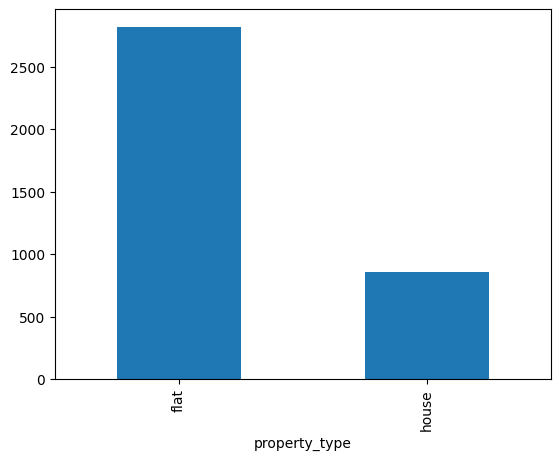

In [11]:
df['property_type'].value_counts().plot(kind = 'bar')

#### Observations
1. Majority of the property type are flats
2. There is no missing value

#### society

In [14]:
df['society'].value_counts().shape

(728,)

In [17]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     38
                                       ... 
spire woods now ananda by alpha corp      1
ss radiance residency                     1
city shri ram apartments 1                1
shree balaji appartment                   1
Hero Homes                                1
Name: count, Length: 728, dtype: int64

In [25]:
df[df['society'] != 'independent']['society'].value_counts(normalize = True).cumsum().head(75)

society
tulip violet                            0.023518
ss the leaf                             0.046410
shapoorji pallonji joyville gurugram    0.059580
dlf new town heights                    0.071496
shree vardhman victoria                 0.082157
                                          ...   
umang monsoon breeze                    0.484164
puri emerald bay                        0.488241
ramsons kshitij                         0.492317
mvn athens                              0.496080
Unitech Uniworld Resorts                0.499843
Name: proportion, Length: 75, dtype: float64

In [27]:
society_counts = df['society'].value_counts()
#Frequency distribution for society
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(274),
 'Very Low (1)': np.int64(359)}

<Axes: xlabel='society'>

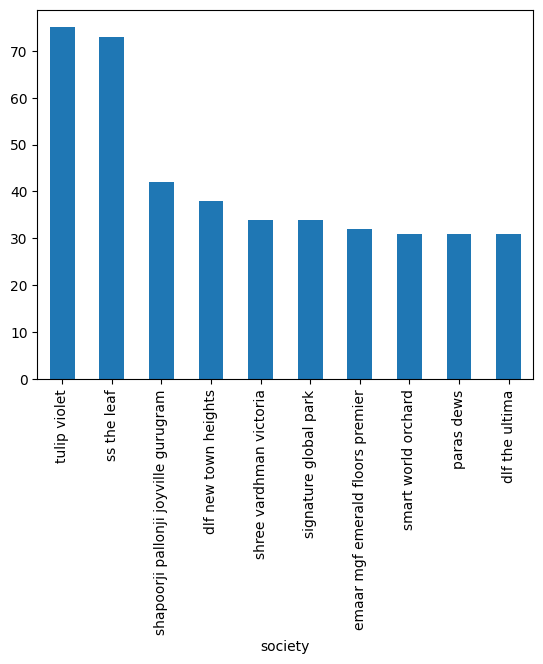

In [29]:
#top 10 societies
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [30]:
df['society'].isnull().sum()

np.int64(1)

In [32]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2479,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


#### Observations
1. About 13% properties come under independent tag
2. There are 727 societies
3. The top 75 societies have 50% of the market share and rest 50% comes under the 650 remaining societies
4. 1 missing value
5. 'Very High (>100)' : 1, Societies with more than 100 properties
6. 'High (50-100)': 2, Societies with properties ranging between 50 and 100
7. 'Average (10-49)': 92, Societies with properties ranging between 10 and 49
8. 'Low (2-9)': 274, Societies with properties ranging between 2 and 9
9. 'Very Low (1)': 359 , Societies with only 1 property

#### sector

In [34]:
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

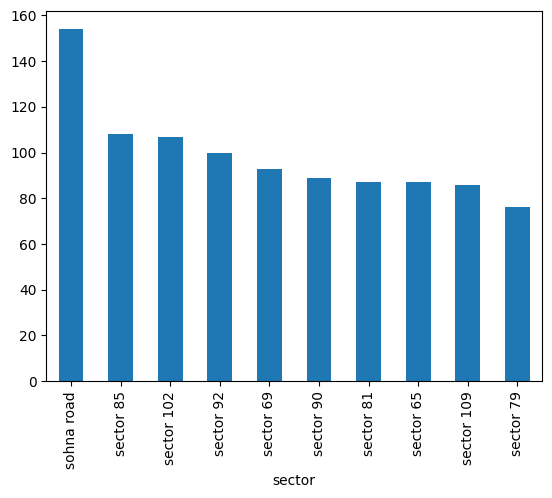

In [36]:
#top 10 sectors
df['sector'].value_counts().head(10).plot(kind = 'bar')

In [38]:
#Frequency dist. for sectors
sector_counts = df['sector'].value_counts()
sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}
sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(22),
 'Very Low (1)': np.int64(1)}

#### Observations
1. There are a total of 113 unique sectors
2. Frequency distribution of sectors:
    - 'Very High (>100)': np.int64(3) , 3 sectors have a listing of more than 100
    - 'High (50-100)': np.int64(25) , 25 sectors have a listing between 50 and 100
    - 'Average (10-49)': np.int64(62) , 62 sectors have a listing between 10 and 49
    - 'Low (2-9)': np.int64(22) , 22 sectors have a listing between 2 and 9
    - 'Very Low (1)': np.int64(1) , 1 sector have a listing of 1

#### price

In [39]:
df['price'].isnull().sum()

np.int64(16)

In [41]:
df['price'].describe() #There seems a problem in unit conversion of price

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

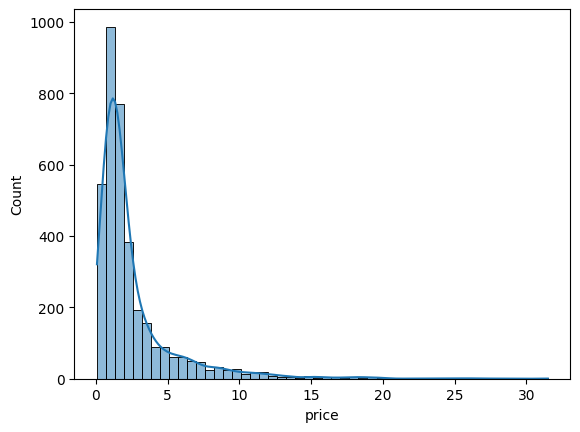

In [42]:
sns.histplot(df['price'] , kde = True , bins = 50)

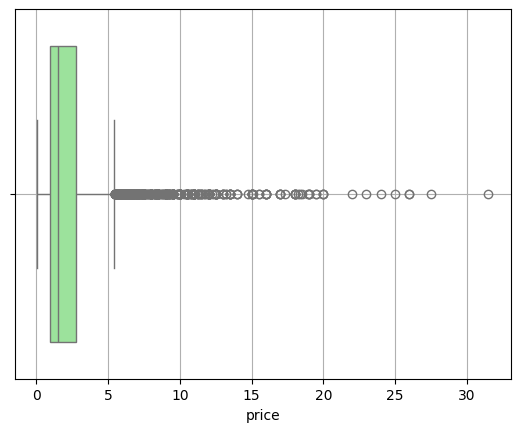

In [43]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

- Descriptive Statistics:

    - Count: There are 3,660 non-missing price entries.
    - Mean Price: The average price is approximately 2.53 crores.
    - Median Price: The median (or 50th percentile) price is 1.52 crores.
    - Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.

- Visualizations:
    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

- Missing Values: There are 16 missing values in the price column.

In [45]:
#skewness and kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()
print(skewness , kurtosis)

3.279170473313463 14.933372629214265


In [46]:
#Quantile analysis
quantiles = df['price'].quantile([0.01 , 0.05 , 0.95 , 0.99])
quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

#### Quantile analysis 
- 1% = only 1% of properties are priced below 0.250 crores
- 5% = only 5% of properties are priced below 0.370 crores
- 95% = 95% properties are priced below 8.5 crores
- 99% = 99% properties are priced below 15.264 crores , indicating there are very few properties that are priced above that price

In [47]:
#identifying potential outliers using iqr method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [48]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [49]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [50]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

#### Outlier analysis using iqr method
- There are 425 properties considered outliers
- These outliers have an average price of 9.235 crores
- The range of these outliers is 5.46 to 31.5 crores

<Axes: xlabel='price'>

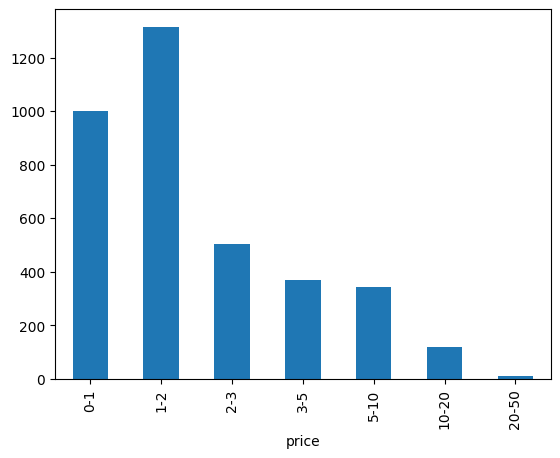

In [57]:
#price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of the properties are in the price range of 0-3 crores
- There is a significant drop in the number of properties above 5 crores as seen in ecdf plot

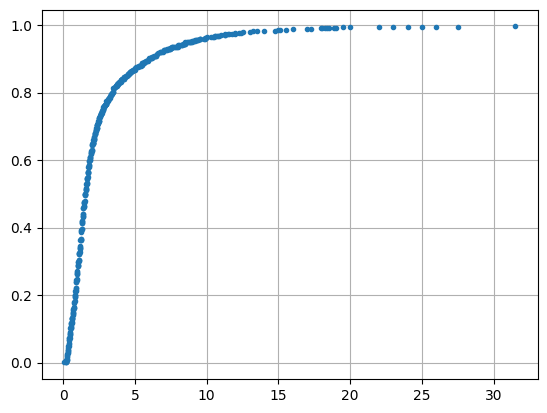

In [58]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

- Because the distribution follows a right skewed distribution thatswhy we need to apply log transformation to make it nearly uniform

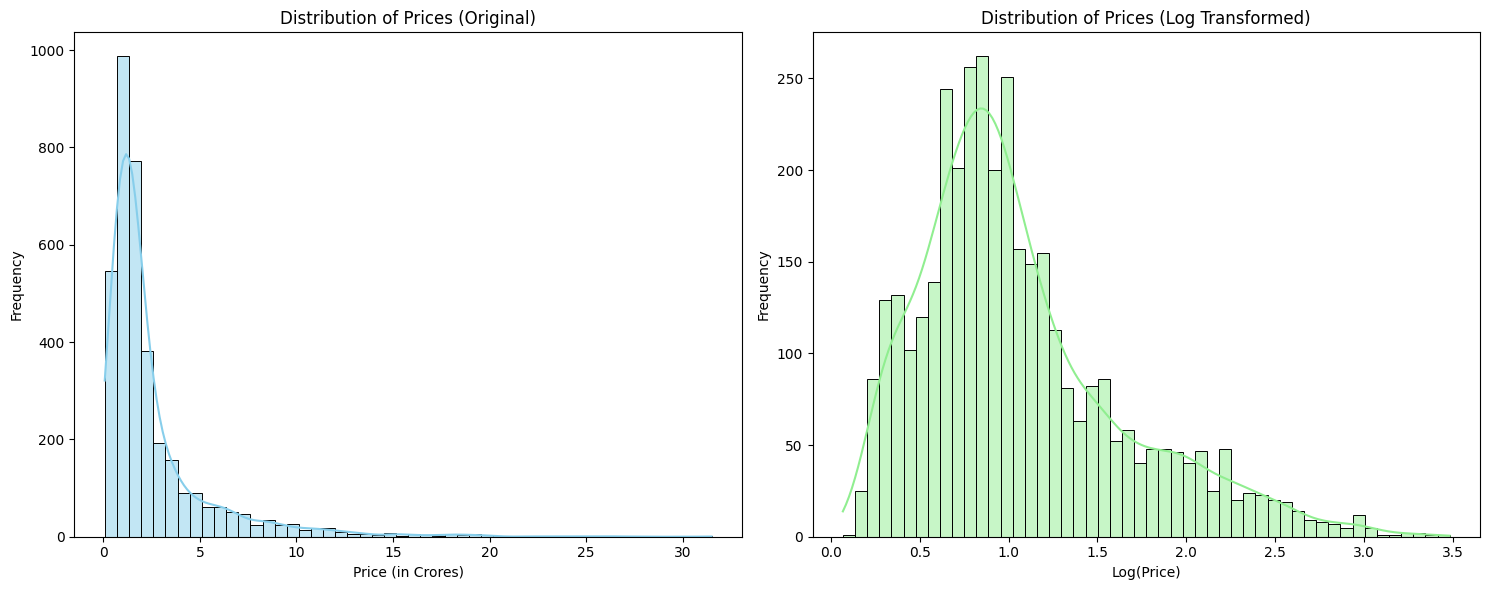

In [59]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [60]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255313 0.9646692415449265


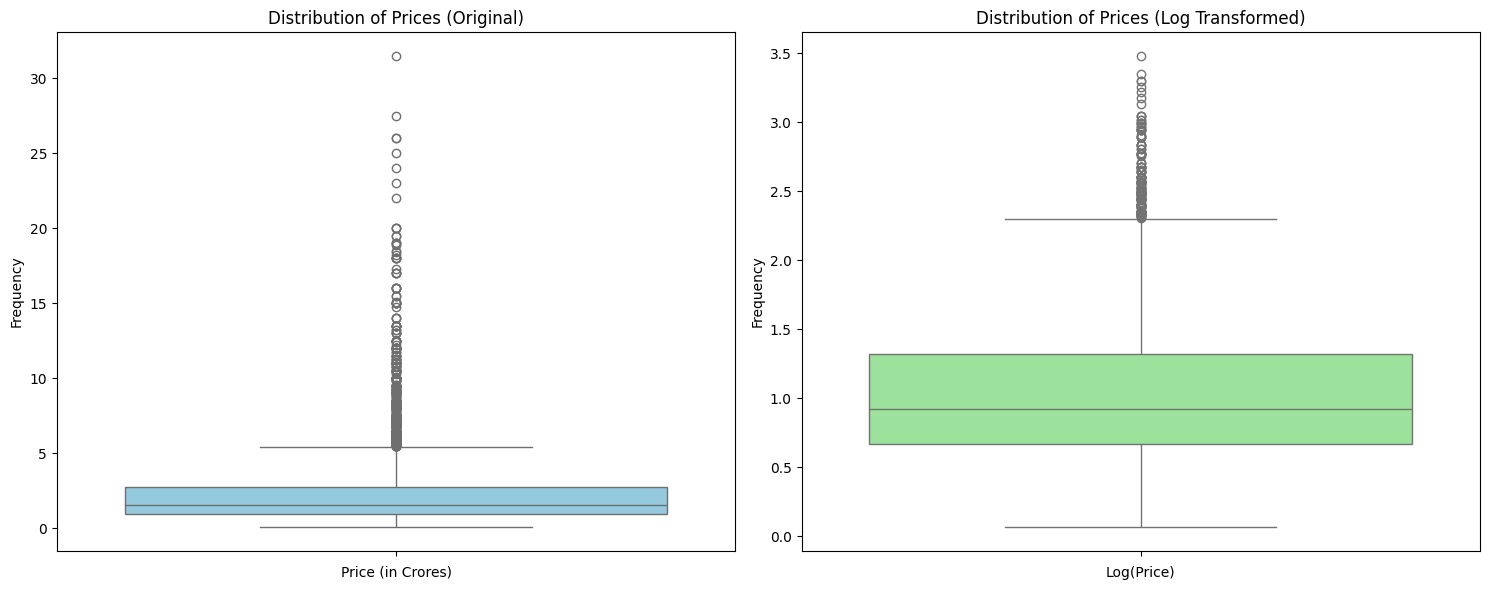

In [61]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### price_per_sqft

In [62]:
df['price_per_sqft'].isnull().sum()

np.int64(16)

In [63]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

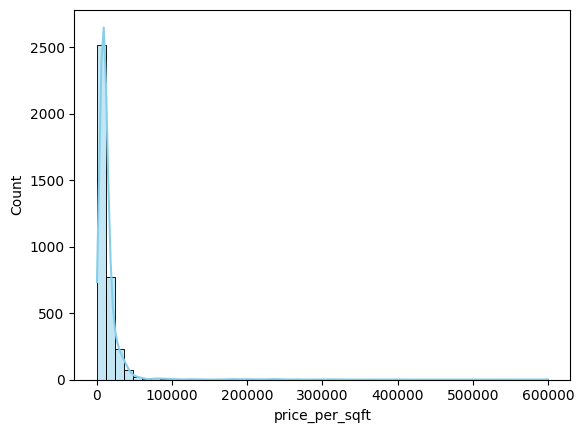

In [64]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_per_sqft'>

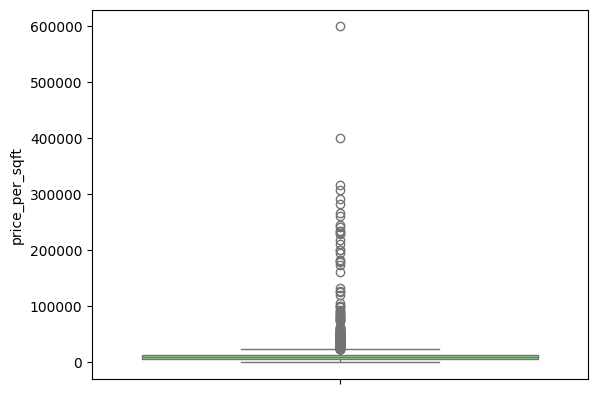

In [65]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

#### Observations
- Potential Outliers
- Right skewed
- 16 missing values

#### bedRoom

In [66]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

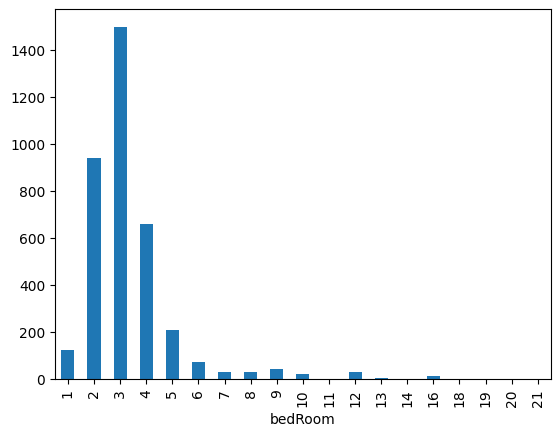

In [70]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: >

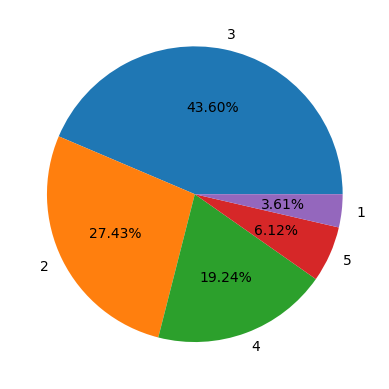

In [71]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

#### bathroom

In [72]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

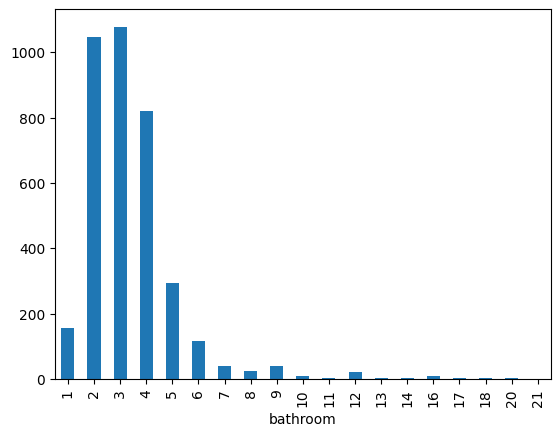

In [73]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: >

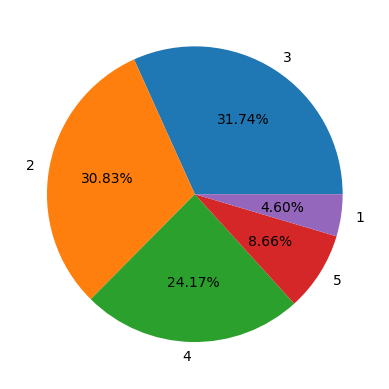

In [74]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [75]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,...,NaN,NaN,6500.0,0,0,0,0,0,1,110
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,...,NaN,250.0,200.0,1,1,1,1,0,0,103
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,...,1930.0,NaN,NaN,0,1,0,0,1,1,113
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,...,NaN,NaN,1650.0,0,0,0,0,0,0,8
4,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,...,NaN,1410.0,NaN,0,0,0,0,0,1,63


#### balcony

In [76]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

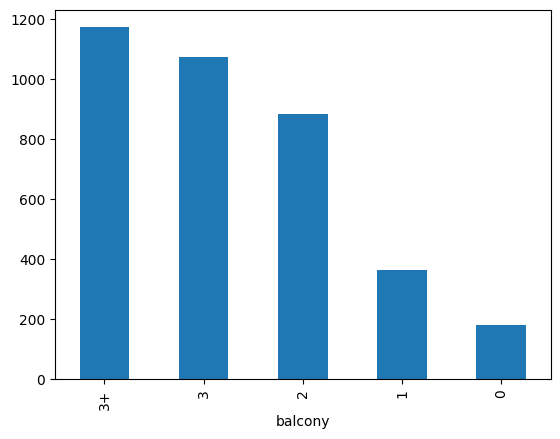

In [77]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: >

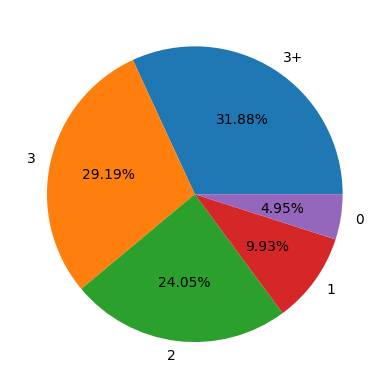

In [78]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

#### floorNum

In [79]:
df.iloc[: , 10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,27.0,North,Relatively New,NaN,NaN,6500.0,0,0,0,0,0,1,110
1,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,0,103
2,5.0,West,Moderately Old,1930.0,NaN,NaN,0,1,0,0,1,1,113
3,8.0,NaN,Relatively New,NaN,NaN,1650.0,0,0,0,0,0,0,8
4,19.0,NaN,Moderately Old,NaN,1410.0,NaN,0,0,0,0,0,1,63


In [80]:
df['floorNum'].isnull().sum()

np.int64(19)

In [81]:
df['floorNum'].describe()

count    3657.000000
mean        6.797101
std         6.012875
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

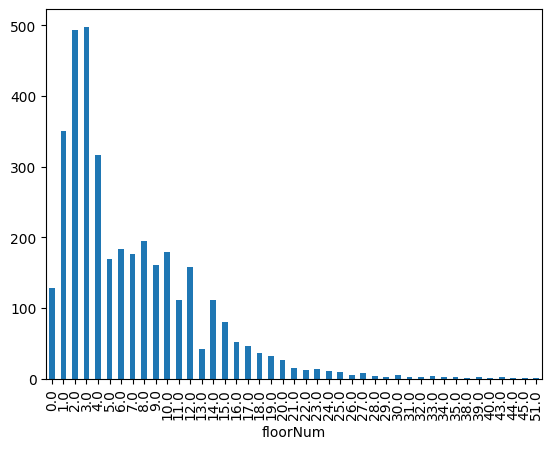

In [82]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

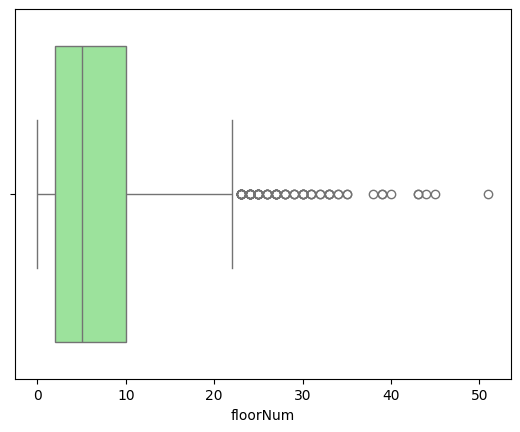

In [84]:
sns.boxplot(df['floorNum'], color='lightgreen' , orient = 'h')

The majority of the properties lie between the ground floor (0) and the 25th floor.

Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.

There are a few properties located at higher floors, but their frequency is much lower.

The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.

Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

#### facing

In [85]:

df['facing'].isnull().sum()

np.int64(1045)

In [88]:
df['facing'] = df['facing'].fillna('NA')

In [89]:
df['facing'].value_counts()

facing
NA            1045
North-East     623
East           622
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

#### agePossession

In [90]:
df['agePossession'].isnull().sum()

np.int64(0)

In [91]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              446
Old Property           303
Under Construction     125
Name: count, dtype: int64

#### areas

In [92]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1801)

In [93]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

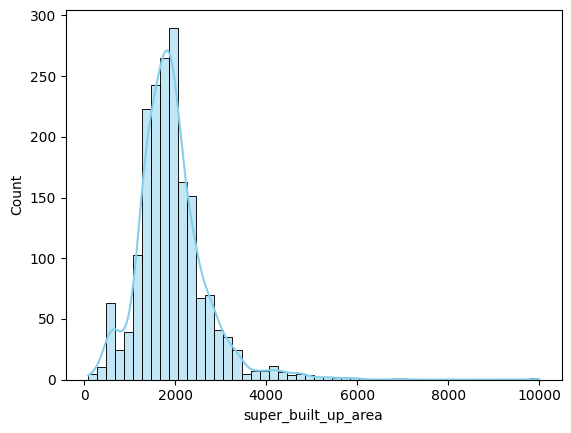

In [94]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

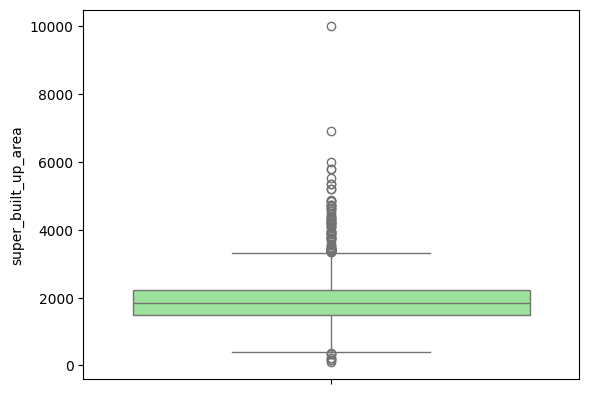

In [95]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.

There are a few properties with a significantly larger area, leading to a right-skewed distribution.

The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.

There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [96]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1986)

In [97]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

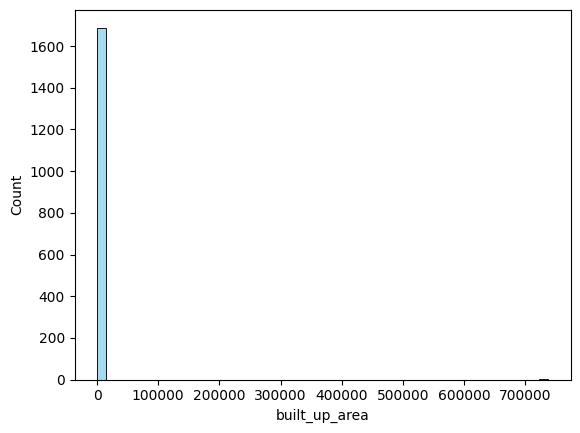

In [98]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

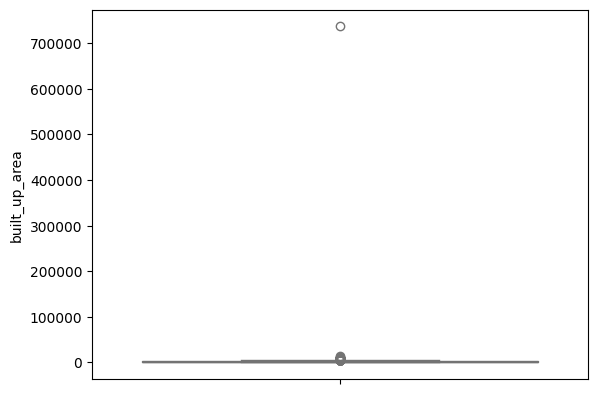

In [99]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.

There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.

The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [100]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1805)

In [101]:
df['carpet_area'].describe()

count      1871.00000
mean       2530.22281
std       22805.88715
min          15.00000
25%         845.00000
50%        1300.00000
75%        1790.00000
max      607936.00000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

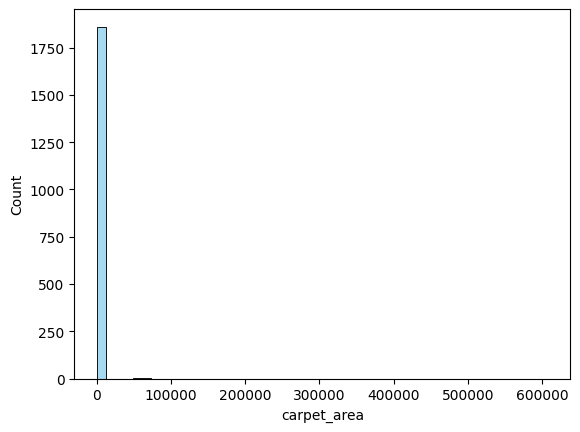

In [102]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

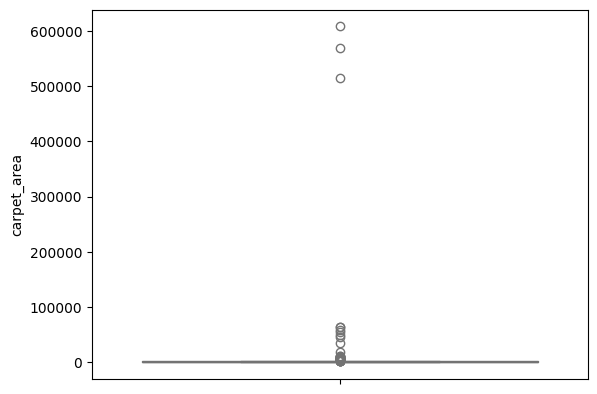

In [103]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [104]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,1,110
1,1,1,1,1,0,0,103
2,0,1,0,0,1,1,113
3,0,0,0,0,0,0,8
4,0,0,0,0,0,1,63
...,...,...,...,...,...,...,...
3796,0,1,0,0,0,0,96
3798,0,0,0,0,0,0,157
3799,0,0,0,0,0,2,0
3800,0,0,0,0,0,1,0


#### additional rooms

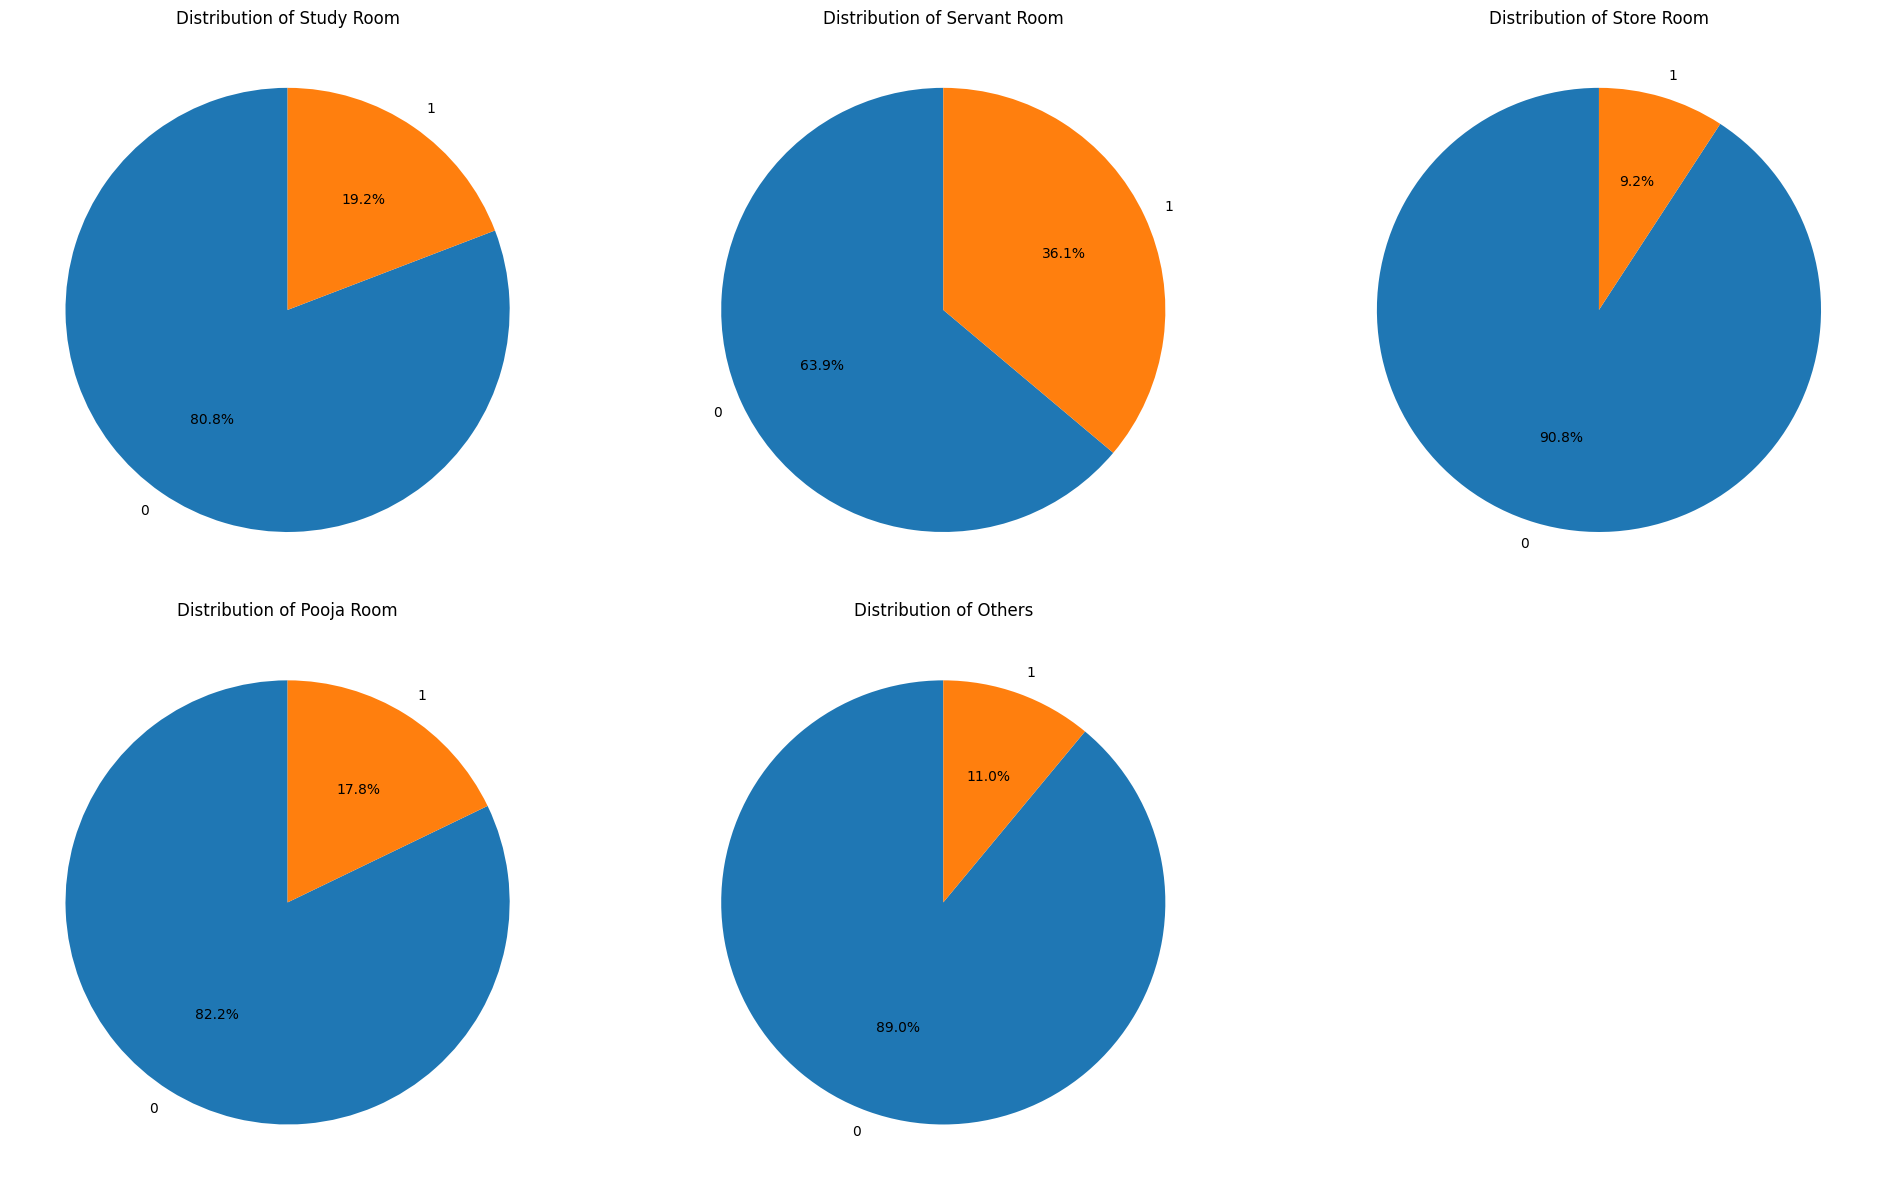

In [105]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#### furnishing_type

In [106]:
df['furnishing_type'].value_counts()

furnishing_type
1    2435
0    1038
2     203
Name: count, dtype: int64

<Axes: >

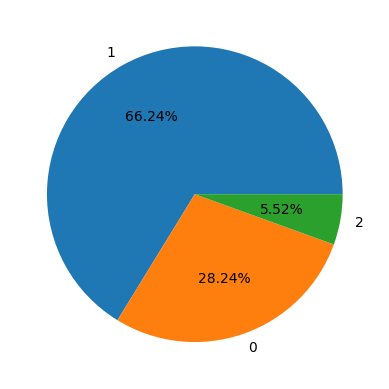

In [107]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

#### luxury_score

In [108]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [109]:
df['luxury_score'].describe()

count    3676.000000
mean       71.281284
std        53.246788
min         0.000000
25%        31.000000
50%        58.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

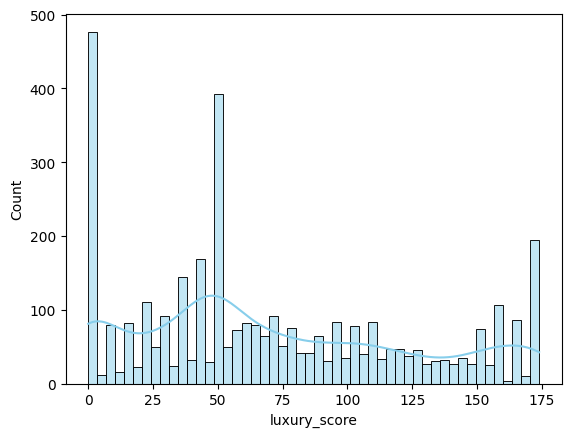

In [110]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

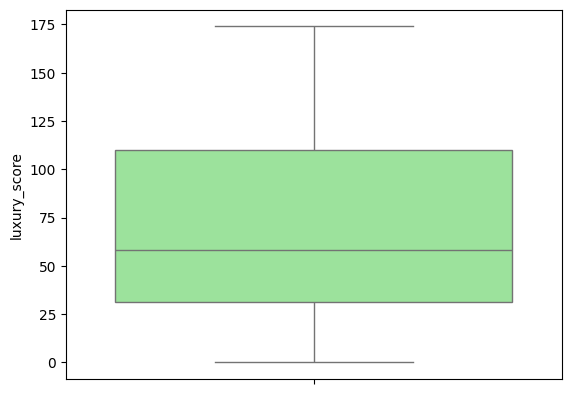

In [111]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [112]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,...,NaN,NaN,6500.0,0,0,0,0,0,1,110
1,house,Unitech Escape3.8 ★,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,...,NaN,250.0,200.0,1,1,1,1,0,0,103
2,flat,dlf new town heights,sector 86,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,...,1930.0,NaN,NaN,0,1,0,0,1,1,113
3,flat,oriental valley chs,sector 9a,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,...,NaN,NaN,1650.0,0,0,0,0,0,0,8
4,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,...,NaN,1410.0,NaN,0,0,0,0,0,1,63
